In [182]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit import *

import matplotlib.pyplot as plt

import numpy as np

# QC III: Quantum Fourier Transform and Phase estimation


It is not entirely unaccurate to suggest that the quantum Fourier transform is the single most important algorithm to quantum computing. 
At the current state of the art, most non-trivial quantum algorithms will either use Grover's algorithm of QFT under the hood to do the
"quantum heavy lifting" -- the rest of the non-trivial matters are usually a matter of classical computation or processing.


While the quantum Fourier transform is of theoretical importance, it can be implemented efficiently -- requiring only $\mathcal{O}(n^{2})$ many gates, 
and can be implemented with some basic quantum gates. The quantum Fourier transform. Similar to how Grover's algorithm was quite a general description of
how you might utilize amplitude amplification for the sake of a search problem, QFT is also more like a broad idea or "technique" that you might use to
solve a more specific type of problem. We will see that some examples of important applications of the QFT "technique" will be 

1. Implementing arithemtic efficiently with quantum circuits

2. Quantum Phase estimation

3. Shor's algorithm


$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

As important as the quantum Fourier transform is, the idea is actually quite simple. Recall that the discrete Fourier transform (DFT) is a general procedure that one can do on the finite dimensional vector space $\mathbb{C}^{N}$ -- one just has to realize that the DFT is in fact a *unitary transformation*. Thus, it is a valid "quantum transformation" that one can apply to a quantum system. Therefore, from a mathematical point of view, the "QFT" is simply just applying the DFT from linear algebra to a finite-dimensional Hilbert space associated to an $n$-qubit system $\mathcal{H}(n)$. The less trivial content involved with the quantum Fourier transform and applying DFT to $\mathcal{H}(n)$ is knowing that the QFT can be effectively realized with a quadratic number of Pauli gates. 


### <u> A quick review of the discrete Fourier transform </U>



<ins>Input:</ins>  Given a function $f : \mathbb{Z}_{N} \rightarrow \mathbb{C}$ 

<ins>Output:</ins> The discrete Fourier transform of $f$ is the function $\mathcal{F}(f)(z) =  \frac{1}{\sqrt{N}} \sum\limits_{x = 0}^{N-1} e^{\frac{2 \pi i ( x \cdot z)  }{N} } f(x) $

<b> Properties of $\mathcal{F}(-)$: </b>

1. $\mathcal{F}$ is a linear map on the space of functions $f: \mathbb{Z}_{N} \rightarrow \mathbb{C}$   ($\cong \mathbb{C}^{N}$)
2. By Parseval's theorem, $\mathcal{F}$ is in fact a unitary map.
3.  For $k \in \mathbb{Z}$, define $T_{k}(f)(x) = f \big(  (x - k) \text{ \tiny  mod N }  \big)$. Then one has 

$$
( \mathcal{F}^{-1} \circ T_{k} \circ \mathcal{F} )(f)(x) = e^{  \frac{2 \pi i( k x ) }{N}} f(x)
$$

<!-- The first two properties means that we can implement this with qubits -- that is, there should be a quantum gate implementation of $\mathcal{F}$ as a map on $\mathcal{C}^{N}$ where $N = 2^{n}$ for some $n$.  -->
The third property essentially says that the DFT transforms "shifts in function argument to shifts in phase".



-------------------------------------------


With the discrete Fourier transform at our disposal, the QFT is the unitary transformation acting on $\mathcal{H}(n)$ in the following way: 
for $\ket{\psi} = \sum\limits_{x \in \mathbb{F}_{2}^{n}} \psi_{x} \ket{x}$, we define

$$
\text{QFT} \ket{\psi} = \frac{1}{\sqrt{2^{n}}} \Big( \sum\limits_{z = 0}^{2^{n} - 1 } \sum\limits_{x = 0}^{2^{n} - 1 }  e^{\frac{2 \pi i }{ 2^{n} } x \cdot z } \psi_{x} \ket{z}   \Big)
$$

Or simpler, if we describe the action of QFT on the computational basis states, QFT is determined by 

$$
\text{QFT} \ket{x} = \frac{1}{\sqrt{2^{n}}} \Big( \sum\limits_{z = 0 }^{2^{n} - 1}  e^{ \frac{2 \pi i}{2^{n}}  x \cdot z  } \ket{z}  \Big)
$$


We can readily compute the inverse transformation to be

$$
\text{QFT}^{\dagger} \ket{x} = \frac{1}{\sqrt{ 2^{n} }} \Big(  \sum\limits_{z = 0 }^{2^{n} - 1}  e^{ - \frac{2 \pi i}{2^{n}}  x \cdot z  } \ket{z} \Big)
$$

------------------------------------------------

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

Let's assume for now that we can effectively construct a quantum gate corresponding to QFT, and take a look at an interesting application of the QFT transformation.


### Draper's adder circuit

Suppose that $k \in \mathbb{Z}$. Draper's adder circuit implements the unitary transformation that acts on the computational basis elements as follows

$$
A(k) \ket{x}_{n}  = \ket{ x + k \text{ (mod } 2^{n}) }_{n}
$$


The idea is here that this transformation is easier to describe and implement in the "Fourier space". Note that 

$$
A(k) \text{QFT}^{\dagger} \ket{x} = \frac{1}{\sqrt{ 2^{n} }} \Big(  \sum\limits_{z = 0 }^{2^{n} - 1}  e^{ - \frac{2 \pi i}{2^{n}}  x \cdot z  } A(k) \ket{z} \Big)
$$

$$
= \frac{1}{\sqrt{ 2^{n} }} \Big(\sum\limits_{z = 0 }^{2^{n} - 1}  e^{ - \frac{2 \pi i}{2^{n}}  x \cdot ( z + k)   + \frac{ 2 \pi i }{2^{n}}( x \cdot k )  } \Big) \ket{ z + k } 
$$

$$
= e^{\frac{2 \pi i }{2^{n}} x \cdot k } \text{QFT}^{\dagger} \ket{x} 
$$

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

Therefore, conjugating $A_{k}$ by $\text{QFT}$ gives

$$
\text{QFT} \circ A(k) \circ \text{QFT}^{\dagger} \ket{x} = e^{\frac{2 \pi i }{2^{n}} x \cdot k } \ket{x}
$$

Therefore, we can write $A_{k}$ as 

$$
A(k) \ket{x} = \text{QFT} \big(     e^{\frac{2 \pi i }{2^{n}} x \cdot k } \text{QFT}^{\dagger} \ket{x}    \big)
$$

Note that $e^{\frac{2 \pi i }{2^{n}} x \cdot k } = \prod\limits_{a = 0}^{n-1} e^{ \frac{ 2 \pi i k  \cdot x_{a}}{2^{n-a} }  }$,
which we can see if we write $x = \sum\limits_{a = 0}^{n-1} x_{a} 2^{a}$. 
In the above expression, if $x_{a} = 0$, then $e^{  \frac{2 \pi i k  \cdot x_{a}}{2^{n-a} }  } = 1$.  


Thus, to implement the gate that acts as $\ket{x} \mapsto  e^{\frac{2 \pi i }{2^{n}} x \cdot k } \ket{x}$, we simply need to use a tensor product of phase gates for each qubit. Recall that the phase gate $P( \theta )$ is defined as follows: 

$$
P(\theta) = \begin{pmatrix} 1 & 0 \\
                            0 & e^{i \theta } \end{pmatrix}
$$

Then, the appropriate tensor product in this context is given by:

$$
A^{QFT}(k) := \bigotimes_{a = 0 }^{n-1} P(\frac{2 \pi }{2^{n-a}} x_{a} \cdot k ) 
$$


So, if we can implement $\text{QFT}$ easily, then we can implement $A(k)$ easily as a quantum circuit. 

--------------------------

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

### On to the implementation of QFT as a quantum circuit...


The key idea that allows us to implement QFT efficiently is the following useful product identity:


$$
\frac{1}{\sqrt{2^{n}}} \Big( \sum\limits_{z = 0 }^{2^{n} - 1}  e^{ \frac{2 \pi i}{2^{n}} \vec{j} \cdot z  } \ket{z}  \Big) 
$$

$$
= \frac{1}{\sqrt{ 2^{n} } }  \bigotimes\limits_{l = 1}^{n}  \Big(  \ket{0} + e^{2 \pi i j 2^{-l} } \ket{1}   \Big)
$$

$$
= \frac{\Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n})} \ket{1}  \Big)  \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n-1} j_{n}) }  \ket{1}  \Big)    \cdots \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{1} \cdots j_{n})  }  \ket{1} \Big) }{ \sqrt{2^{n}}}
 $$
In the above identity, we are considering $\vec{j}$ as an $n$-digit binary number, represented as a vector in $\mathbb{F}^{n}_{2}$. Furthermore, we adopt the notation $0.j_{l} \cdots j_{m} = j_{l} / 2 + j_{l+1} / 4 + \cdots + j_{m} / 2^{m-l + 1}$ for binary rational numbers (aka dyadic rational numbers)


The product identity above essentially shows us how to define an efficient circuit for applying the QFT on a state $\ket{j}$ encoding an integer $j$. We will need to apply a number of *controlled* phase gates on each qubit in the register: depending on the index of the qubit $\ket{j_{k}}$ in the order $\ket{j_{1}, \cdots , j_{n}}$ above, we need to rotate $\ket{0}$ to the state $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n-k}  \cdots j_{n}) }  \ket{1} )$.

 <!-- The rotation gates we will use are known as phase gates. Define:

$$
R_{k} := \begin{pmatrix} 1 & 0 \\ 0 & e^{2 \pi i / 2^{k} } \end{pmatrix}
$$ -->
<!-- 
In Qiskit, this is written as $P( \pi / 2^ {k-1} ) = R_{k}$.  -->



Then, the idea is to first apply a Hadamard gate which takes $\ket{0} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + \ket{1} )$ and $\ket{1} \mapsto \frac{1}{\sqrt{2}}( \ket{0} - \ket{1})$, 
then applying a sequence of these phase gates above will rotate the $\ket{1}$-coordinate of the state vector to the correct position. 

For example, consider the first qubit in the register. We would like to produce the state $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} \cdots j_{n} } \ket{1} )$ from $\ket{j_{1}}$. This is done by sending $\ket{j_{1}}$  through a sequence of transformations

$$
\ket{j_{1}} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} } \ket{1} )  \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} } \ket{1} ) \mapsto \cdots \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} \cdots j_{n} } \ket{1} ) 
$$

<!-- 
 producing the state $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} } \ket{1} ) \ket{ j_{2} \cdots j_{n} }$, then  -->

Consider the first transformation in this sequence, $\ket{j_{1}} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} } \ket{1} )$.
If $\ket{j_{1}} = \ket{0}$, then this should be $\frac{1}{\sqrt{2}}( \ket{0} + \ket{1} )$. If $\ket{j_{1} } = \ket{1}$, then this should be $\frac{1}{\sqrt{2}}( \ket{0} -\ket{1} )$. This first transformation is simply the Hadamard gate, with no following rotations. 


The next transformation is a controlled phase gate. We must rotate $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} } \ket{1} )$ to $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} } \ket{1} )$. If $j_{2} = 0$, then this is just an identity transformation, as $0.j_{1}j_{2} = 0.j_{1}$ in this case. If $j_{2} = 1$, then  $0.j_{1}j_{2} = 0.j_{1} + 1/4$, so $ e^{2 \pi i 0.j_{1} j_{2} } = e^{2 \pi i / 4 }  e^{2 \pi i 0.j_{1}}$. That is, we can achieve this by applying the phase gate $P( 2 \pi / 4) = P( \pi / 2 )$, controlled on $\ket{j_{2}}$.

 <!-- In what follows, we will use the notation $R_{k} := P( \pi / 2^ {k-1} )$.  -->


Similarly, by applying the sequence of phase gate $P( 2 \pi / 2^{3}), P( 2 \pi / 2^{4} ), ...$ controlled on $\ket{j_{3}} , \ket{j_{4}} , ...$ respectively, we will arrive at the state $\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} \cdots j_{n} } \ket{1} )$ for the first qubit. Overall, the system will go from $\ket{j_{1} , j_{2}, \cdots , j_{n}}$ to 
$\frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} \cdots j_{n} } \ket{1} ) \ket{j_{2}, \cdots , j_{n}}$. 

The second qubit should go from $\ket{j_{2}} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{2} j_{3} \cdots j_{n} } \ket{1} )$. So, we can follow the same steps as above, omitting $j_{1}$. That is, first apply $H$, then apply controlled $P( 2 \pi / 2^{3}), P( 2 \pi / 2^{4} ), ...$ gates controlled on $\ket{j_{3}}, \ket{j_{4}}, \cdots $ respectively. 

Applying this for all the qubits $\ket{j_{i}}$ in the register $\ket{j_{1}, \cdots , j_{n}}$, we will arrive at the state


$$
\frac{ \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{1} \cdots j_{n})  }  \ket{1} \Big)  \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{2} \cdots j_{n})  }  \ket{1} \Big) \cdots  \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n-1} j_{n}) }  \ket{1}  \Big)     \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n})} \ket{1}  \Big)  }{ \sqrt{2^{n}}}
$$

which is the desired QFT product state as described above, but in reverse. Applying appropriate SWAP gates leaves us with the desired state 

$$
\frac{\Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n})} \ket{1}  \Big)  \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{n-1} j_{n}) }  \ket{1}  \Big)    \cdots \Big( \ket{0} + e^{2 \pi i ( 0 \cdot j_{1} \cdots j_{n})  }  \ket{1} \Big) }{ \sqrt{2^{n}}}$$

<!-- 
For the second qubit, we would like to map $\ket{j_{2}} \mapsto \frac{1}{\sqrt{2}}( \ket{0} + e^{2 \pi i 0.j_{1} j_{2} } \ket{1} )$. The angle $0.j_{1}j_{2} = j_{1}/2 + j_{2}/4$ is such that if $j_{1} = 0$ then  $e^{2 \pi i 0.j_{1} j_{2} } = e^{ \pi i / 2 }$


 -->


In [183]:
def quantum_fourier_transform(n):
    input_register = QuantumRegister(size=n, name="x")
    QFT_circuit = QuantumCircuit(input_register, name=f"QFT")

    for q, p in zip(input_register[:n >> 1], reversed(input_register[n >> 1:])):
        QFT_circuit.swap(q, p)

    for i, q in enumerate(input_register, start=1):
        QFT_circuit.h(q)
        for j, p in enumerate(input_register[i:], start=1):
            QFT_circuit.cp(np.pi / (1 << j), q, p)

    return QFT_circuit

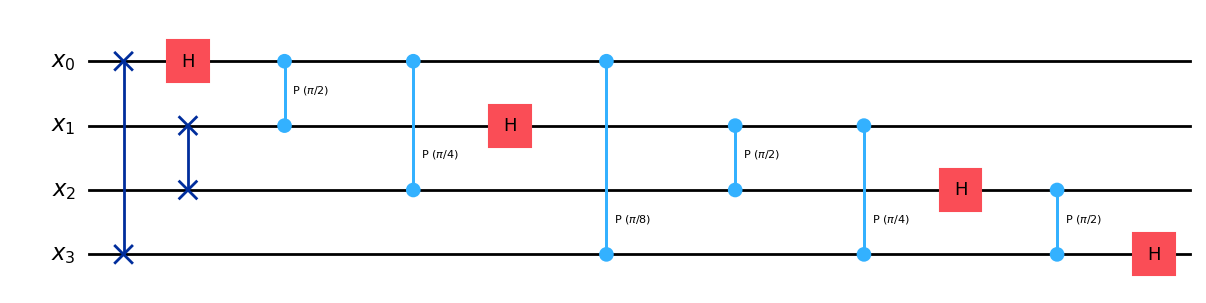

In [184]:
qft_circuit = quantum_fourier_transform(4)
qft_circuit.draw('mpl')

The inverse QFT circuit can be given by just doing the QFT circuit in reverse, with a sign flip for the angles. 

In [185]:
def inverse_quantum_fourier_transform(n):
    quantum_register = QuantumRegister(size=n, name="x")
    inverse_QFT_circuit = QuantumCircuit(quantum_register, name=f"IQFT")

    for i, q in enumerate(reversed(quantum_register), start=1):
        for j, p in enumerate(reversed(quantum_register[n + 1 - i:]), start=1):
            inverse_QFT_circuit.cp(- np.pi / (1 << (i - j)), q, p)
        inverse_QFT_circuit.h(q)

    for q, p in zip(quantum_register[:n >> 1], reversed(quantum_register[n >> 1:])):
        inverse_QFT_circuit.swap(q, p)

    return inverse_QFT_circuit

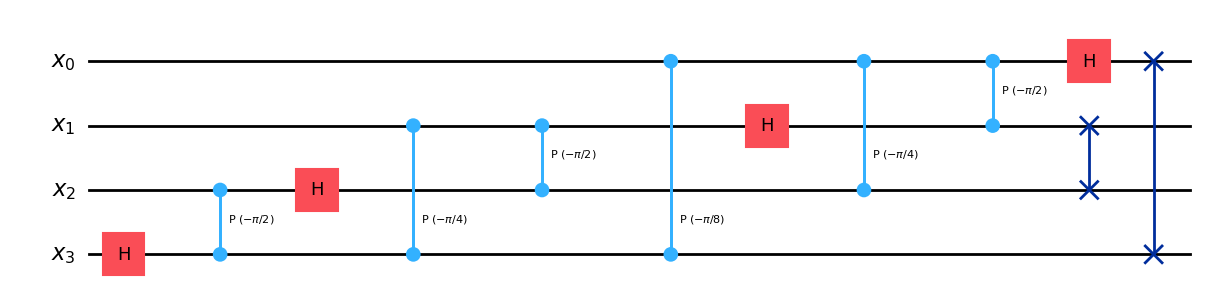

In [186]:
qft_inv_circuit = inverse_quantum_fourier_transform(4)
qft_inv_circuit.draw('mpl')

Now we have QFT and QFT inverse circuits, we can implement the Draper Adder circuit in qiskit. 

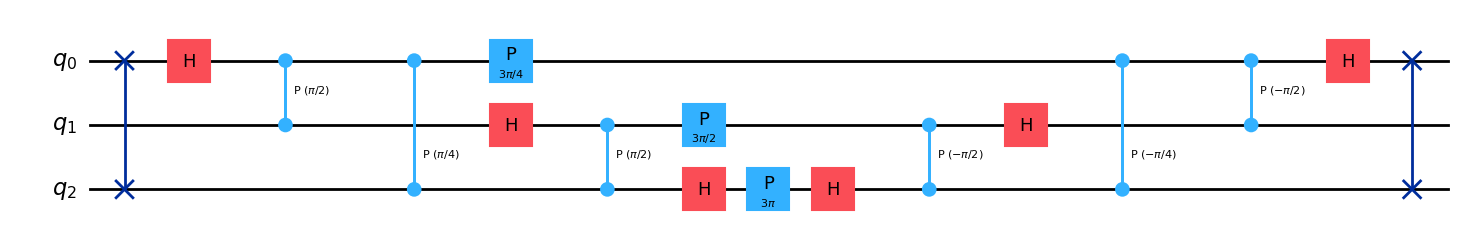

In [187]:
def Draper(k, n):
        
    draper_circuit = QuantumCircuit(n)
    draper_circuit.compose(  quantum_fourier_transform(n), inplace=True )
    
        
    for idx,qubit in enumerate(draper_circuit.qubits):
        draper_circuit .p( (2 * np.pi * k )/2**(n - idx), qubit )
        
    draper_circuit.compose( inverse_quantum_fourier_transform(n), inplace=True )
    
    return draper_circuit

draper_circuit = Draper(3, 3)
draper_circuit.draw('mpl')

In [188]:
statevector = Statevector( draper_circuit )

statevector.draw('Latex')

<IPython.core.display.Latex object>

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

This is the deterministic output state of the Draper circuit $A(3)$, if we start from the initial state of $\ket{000}$. 


------------------------------------------

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

### Fejér states

The above Draper adder circuit $A(k)$ was defined for $k \in \mathbb{Z}$. However, at the end of the day, $A(k)$ is simply defined by conjugating the tensor product of phase gates $A^{QFT}(k) := \bigotimes\limits_{a = 0 }^{2^{n} - 1} P(   \frac{2 \pi}{2^{n-a}} x_{a} \cdot k )$ by $\text{QFT}$. So, $A(k)$ makes sense even if $k$ is not an integer. 

> Definition:
> For any real number $\theta$, we define $\ket{\theta}_{F} := A(\theta) \ket{0}$ to be the Fejér state associated to $\theta$ 

Note that if $\theta$ is an integer $k$, then $\ket{\theta}_{F} = \ket{k}$. Let's see what $\ket{\theta}_{F}$ looks like for non-integer $\theta$. We have 

$$
\begin{align*}
&\text{QFT}^{\dagger} \circ A^{QFT}( \theta ) \circ \text{QFT} ( \ket{0} ) \\
& = \text{QFT}^{\dagger} \circ A^{QFT}( \theta )   \Big(  \frac{1}{\sqrt{2^{n}} } \sum\limits_{y}^{2^{n}  - 1 } \ket{y}  \Big)\\
& = \text{QFT}^{\dagger} \circ \Big(  \frac{1}{\sqrt{2^{n}} } \sum\limits_{y}^{2^{n}  - 1 } e^{\frac{2 \pi i}{2^{n}} \theta y }  \ket{y}  \Big)\\
& = \frac{1}{2^{n}} \sum\limits_{y,z = 0}^{2^{n}-  1 } e^{ \frac{2 \pi i}{2^{n}} \theta y  } e^{-\frac{ 2 \pi i}{2^{n}} zy  } \ket{z}\\
& = \frac{1}{2^{n}} \sum \limits_{z = 0}^{2^{n} - 1 } \Big(  \sum \limits_{y = 0 } ^{2^{n} - 1 } e^{\frac{2 \pi i}{2^{n}} ( \theta - z ) y} \ket{z}  \Big)
\end{align*}
$$

Now, viewing  $\sum \limits_{y = 0 } ^{2^{n} - 1 } e^{\frac{2 \pi i}{2^{n}} ( \theta - z )y} = \sum \limits_{y = 0 } ^{2^{n} - 1 } \Big( e^{\frac{2 \pi i}{2^{n}} ( \theta - z ) } \Big)^{y}  $ as a geometric series with ratio $e^{\frac{2 \pi i}{2^{n}} ( \theta - z ) }$, we then get 
$$
\begin{align*}
&\frac{1}{2^{n}} \sum \limits_{z = 0}^{2^{n} - 1 } \Big(  \sum \limits_{y = 0 } ^{2^{n} - 1 } e^{\frac{2 \pi i}{2^{n}} ( \theta - z ) y} \ket{z}  \Big) \\
&= \frac{1}{2^{n}} \sum\limits_{z = 0}^{2^{n} - 1 } \frac{  e^{\frac{2 \pi i}{2^{n}} ( \theta - z ) \cdot 2^{n} } - 1   }{  e^{\frac{2 \pi i}{2^{n}} ( \theta - z ) }  - 1  } \ket{z} \\
&= \frac{1}{2^{n}} \sum\limits_{z = 0}^{2^{n} - 1 } \frac{  e^{2 \pi i ( \theta - z ) } - 1   }{  e^{\frac{2 \pi i}{2^{n}} ( \theta - z ) }  - 1  }   \ket{z} \\
&= \sum\limits_{z = 0}^{2^{n} - 1 } \frac{  \sin(2 \pi  ( \theta - z ) )  }{ 2^{n} \sin( \frac{2 \pi i}{2^{n}} ( \theta - z ) )  }  \frac{ e^{2 \pi i ( \theta - z ) }  }{ e^{\frac{2 \pi i}{2^{n}} ( \theta - z ) } } \ket{z} \\
&= \sum\limits_{z = 0}^{2^{n} - 1 } \frac{  \sin(2 \pi  ( \theta - z ) )  }{ 2^{n} \sin( \frac{2 \pi i}{2^{n}} ( \theta - z ) )  }  e^{(1 - \frac{1}{2^{n}} ) \pi i ( \theta - z ) }  \ket{z}
\end{align*}
$$
(where we used that $\sin(z) = \frac{ e^{iz} -  e^{- i z } }{ 2i }$)


So, for a non-integer $\theta$, the associated Fejér state is a superposition of states $\ket{z}$ encoding integers $z \in \mathbb{Z}$ (in the computational basis). 
The probability of measuring any of these integers $z$ is given by 

$$
\mathbb{P} \Big( z \Big| \ket{\theta}_{F} \Big)  =  | \bra{ z } \ket{\theta}_{F} |^{2} = \frac{  \sin^{2}(2 \pi  ( \theta - z ) )  }{ 4^{n} \sin^{2}( \frac{2 \pi }{2^{n}} ( \theta - z ) )  } 
$$
(these distributions are known as Fejér kernels, they have fairly well understood shapes)


#### What is the most likely integer one can measure from a Fejér state?  

Suppose that $\theta = z_{\theta} + r$ where $z_{\theta}$ is the nearest integer to $\theta$, so that $ -1/2 \leq r \leq 1/2$. Then, we can rewrite the above Fejér kernel as 

$$\mathbb{P} \Big( z_{\theta} \Big| \ket{\theta}_{F} \Big) =  \frac{  \sin^{2}(2 \pi   r  )  }{ 4^{n} \sin^{2}( \frac{2 \pi }{2^{n}}  r  ) }$$

As $r \mapsto 0$, we can see that the above probability tends to $1$ , as $\sin(x) \approx x$ for small $x$. One can also easily verify that this probability is bounded below by the case where $|r| = \frac{1}{2}$. In that case, we have that 

$$\mathbb{P} \Big( z_{\theta} \Big| \ket{\theta}_{F} \Big) =  \frac{  \sin^{2}( \frac{\pi}{2}   )  }{ 4^{n} \sin^{2}( \frac{ \pi }{2^{n+1}}    ) } \geq \frac{4}{\pi^{2}} \approx 0.405 $$

Therefore, we can say that the probability of measuring either $\lfloor \theta \rfloor$ or $ \lceil \theta \rceil$  is given by

$$\mathbb{P} \Big(   \lfloor \theta \rfloor  \Big| \ket{\theta}_{F} \Big) + \mathbb{P} \Big(   \lceil \theta \rceil  \Big| \ket{\theta}_{F} \Big) \geq 0.81$$

To summarize, when $\theta$ is not an integer, $\ket{\theta}_{F} := A(\theta) \ket{0}$ is a superposition over basis states $\ket{z}$ for $z = 0,...,2^{n}-1$. The probability of measuring any one of these integers follows a distribution determined by well-known Fejér kernels. The most likely integer you can measure will be the closest integer to $\theta$. If $\theta$ itself is an integer, then we will measure $\ket{\theta}$ with certainty.  

While these Fejér states are of theoretical importance (they are also among the states that give us more interesting measurement probability distributions that we've looked at so far), they are also of practical importance -- as we will see next with the quantum phase estimation algorithm.
Perhaps these Fejér states $\ket{\theta}_{F}$ can be thought of as "fuzzy integers", which would be of interest if we are hoping to encode non-integer numerical data. For example, we may wish to compute eigenvalues of certain operators. 


Before we move onto quantum phase estimation, let us demonstrate the above in qiskit. We will define a circuit that prepares a Fejér state with respect to some $\theta$ (whose nearest integer needs up to $n$ bits), and then examine some measurement probabilities 

We will need the inverse QFT for the state preparation. Furthermore, recall that $\text{QFT}\ket{0}_{n} = H^{\otimes n} \ket{0}_{n}$. This allows us to take a shortcut and write

$$
| \theta \rangle_F := \tfrac{1}{2^n} \sum\limits_{x = 0}^{2^n - 1} \exp \left( \tfrac{2 \pi i}{2^n} \left( \theta - x \right) \right) | x \rangle = QFT^\dagger \circ A^{QFT}( \theta ) \circ H^{\otimes n} | 0 \rangle_n.
$$

We look at an example where we take $\theta = 64.5$, which is right in between $64$ and $65$. Thus, we are in the case here where $r = 1/2$. By the discussion above, measuring $64$ has probability around 40.5%, as does measuring $65$.   

In [189]:
n = 7
theta = 2**(n - 1) + 0.5
n, 2**n, theta 

(7, 128, 64.5)

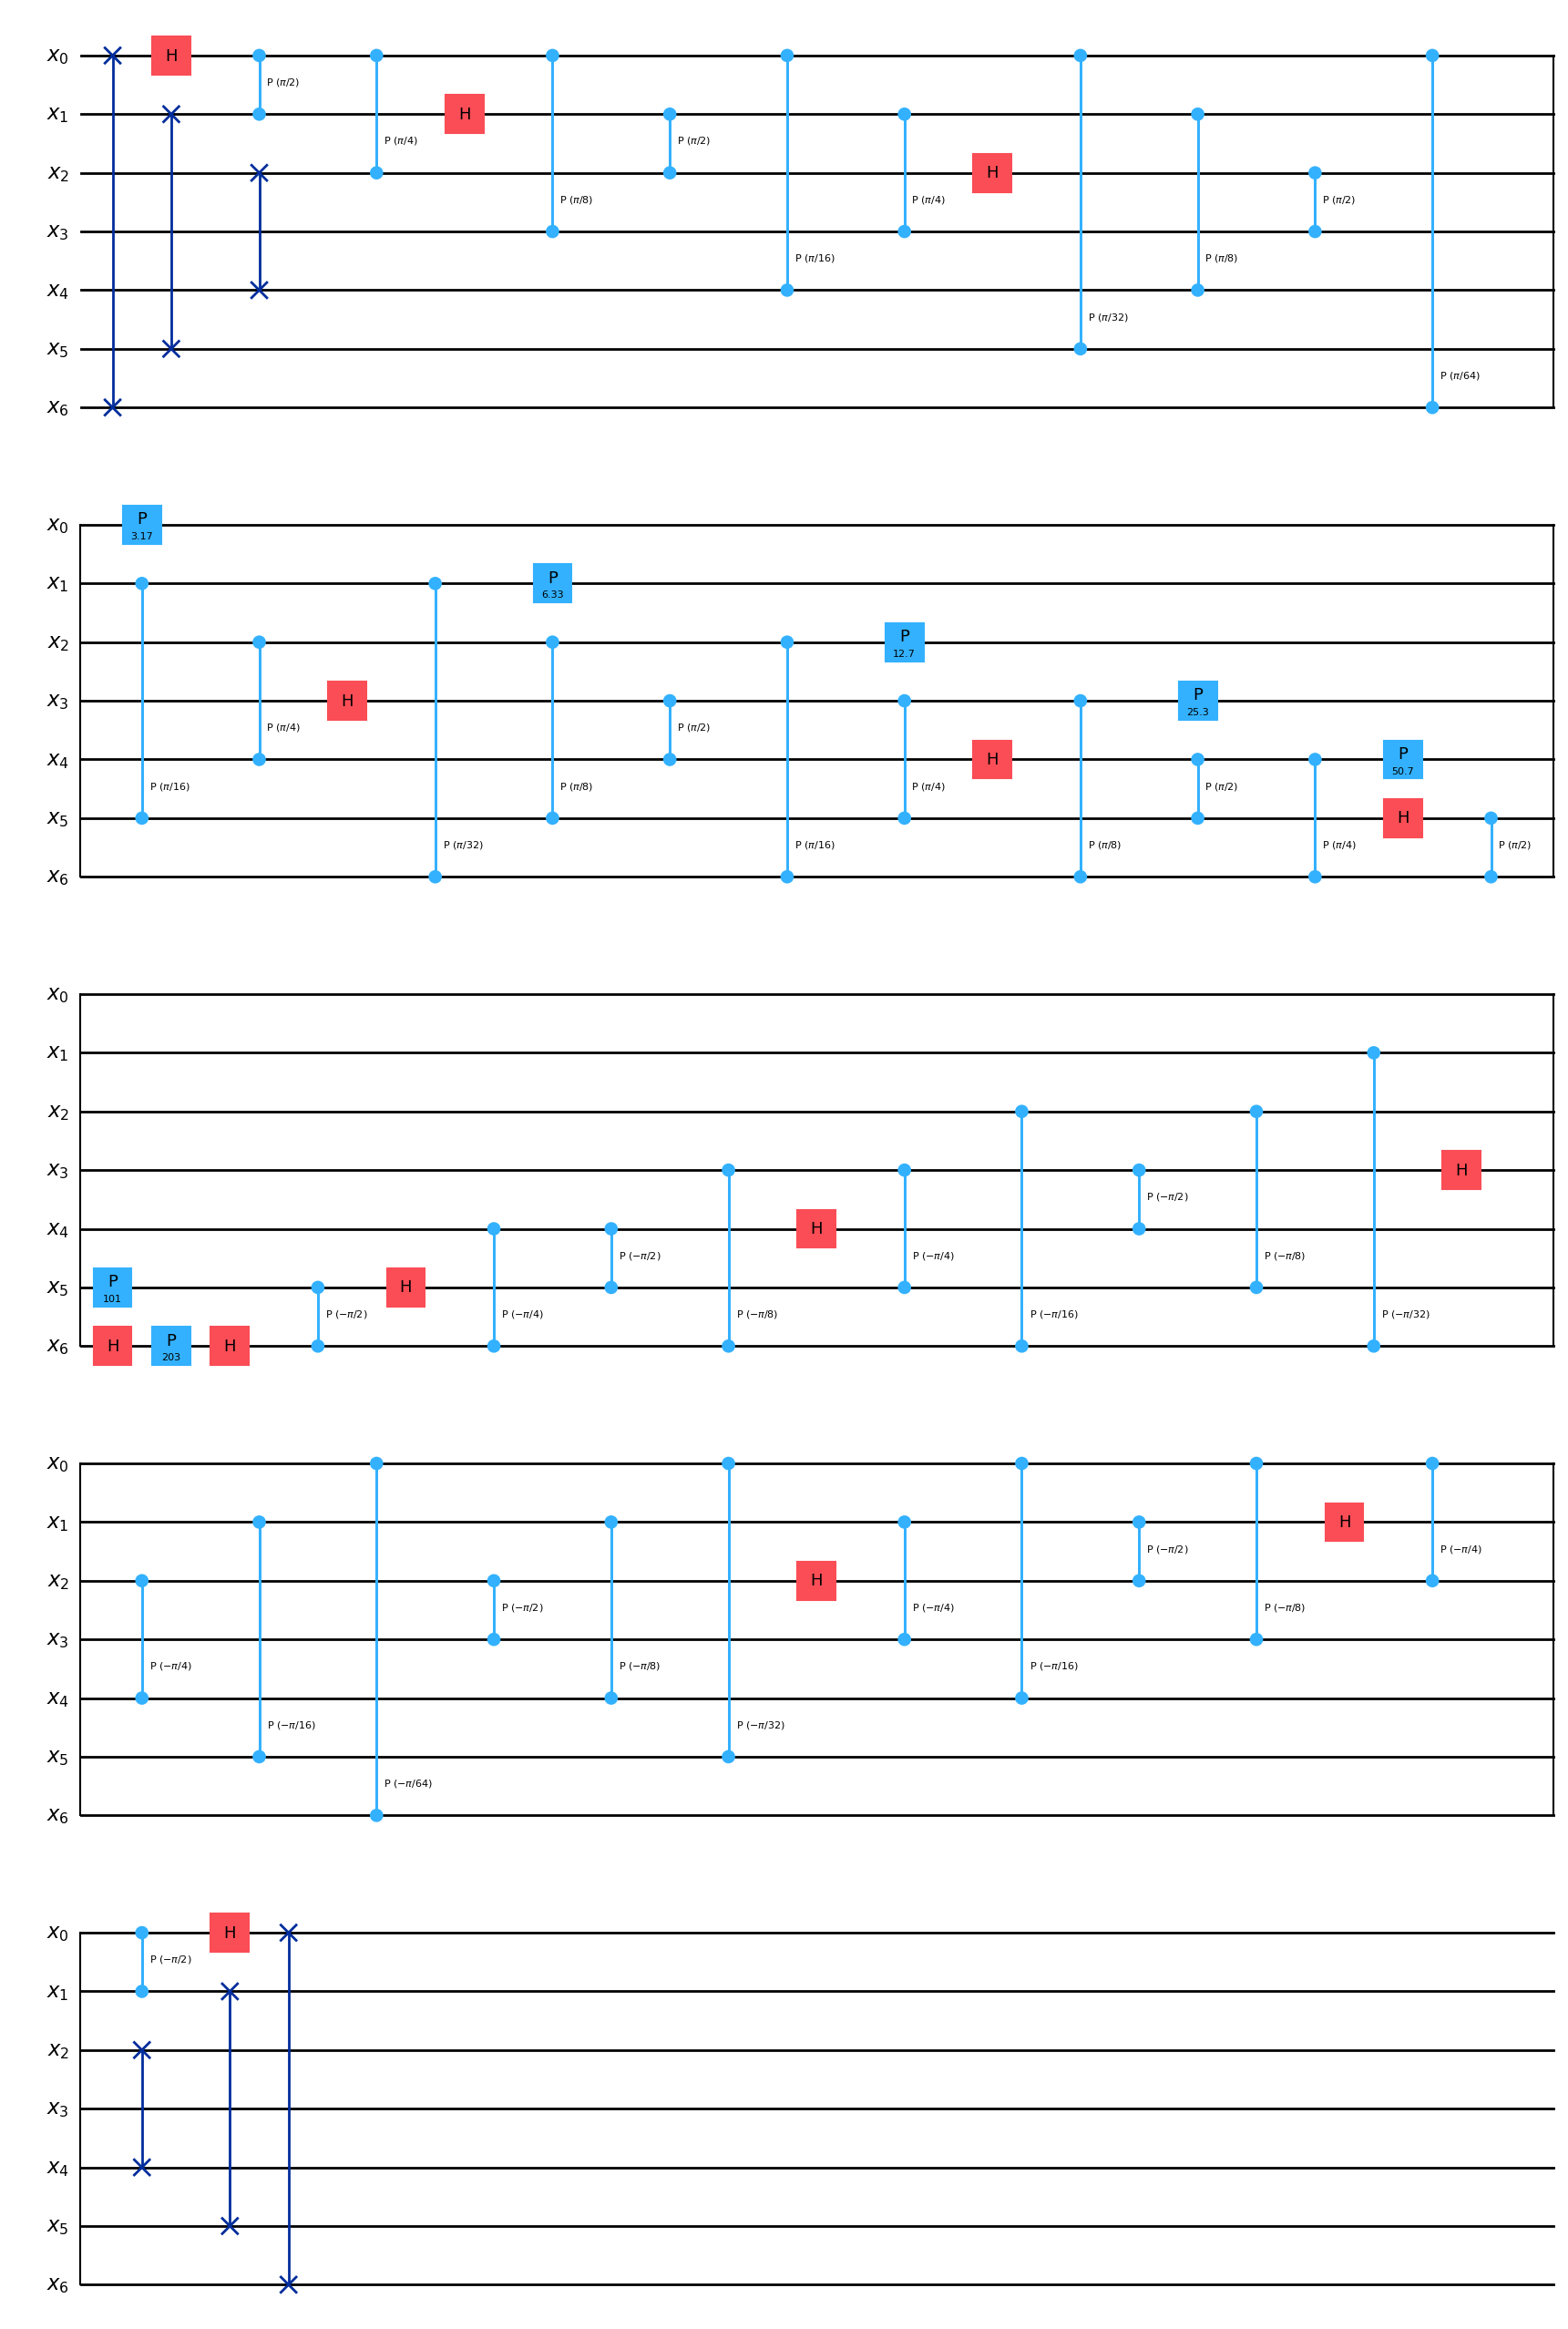

In [190]:
def fejer_prep(theta,n):
    quantum_register = QuantumRegister(size=n, name="x")
    fejer_circuit = QuantumCircuit(quantum_register, name=r"circuit for | theta \rangle_F")
    fejer_circuit.compose( Draper(theta,n) , inplace=True )
    
    return fejer_circuit 

fejer_circuit = fejer_prep(theta,n)
fejer_circuit.draw(output="mpl")



In [191]:
fejer_distribution = Statevector(fejer_circuit).probabilities()

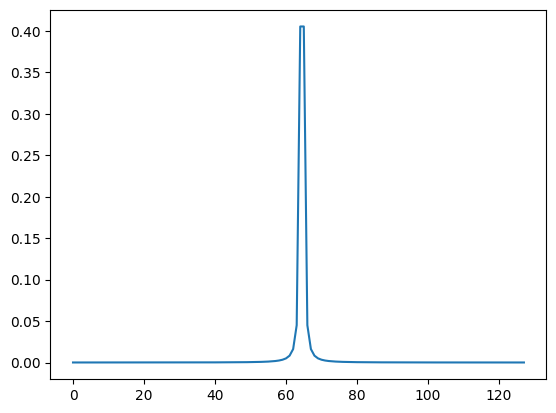

In [192]:
plt.plot(np.arange(2**n), fejer_distribution)

In [193]:
theta_low = int(np.floor(theta))
theta_high = int(np.ceil(theta))

theta_low, theta_high

(64, 65)

So, measuring $64$ or $65$ does indeed have a probability of around 40%. If we look at the probability of measuring *either* $64$ or $65$, we should get around 81%.

In [194]:
fejer_distribution[theta_low] + fejer_distribution[theta_high], 8 / np.pi**2

(np.float64(0.8106101604684677), 0.8105694691387022)

If we take $\theta$ to be much closer to an integer, we will see a larger probability spike around the nearest integer. 

In [195]:
theta =  50.102154392574949

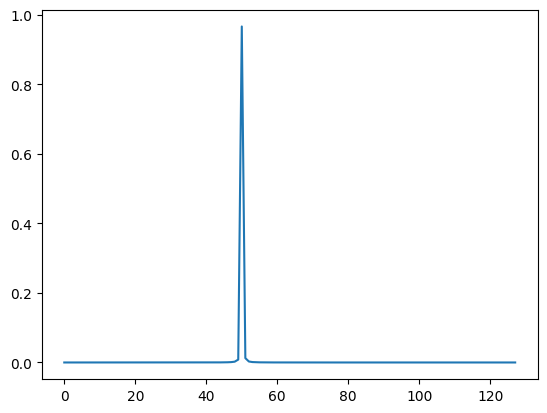

In [196]:
fejer_circuit = fejer_prep(theta,n)
fejer_distribution = Statevector(fejer_circuit).probabilities()
plt.plot(np.arange(2**n), fejer_distribution)

In [197]:
theta_low = int(np.floor(theta))
theta_high = int(np.ceil(theta))

theta_low, theta_high

(50, 51)

In [198]:
fejer_distribution[theta_low] , fejer_distribution[theta_high]

(np.float64(0.9661385477634562), np.float64(0.012508912852910638))

Here we see that there is around a 97% chance that we will measure the floor of $\theta$. The combined probability won't be much higher, as the probability of measuring anything other than $\lfloor \theta \rfloor$ is quite low. 

In [199]:
fejer_distribution[theta_low] + fejer_distribution[theta_high], 8 / np.pi**2

(np.float64(0.9786474606163669), 0.8105694691387022)

Feel free to play around with different choice of the parameters to experiment with the measurement probabilities.

theta is 32.41239463155997
the probability of measuring the floor of theta is 0.5517838907522188
the probability of measuring the ceiling of theta is 0.27179332901260095
the probability of measuring either floor or ceiling is 0.8235772197648197
compared to 8 / pi^2 , which is around 0.8105694691387022


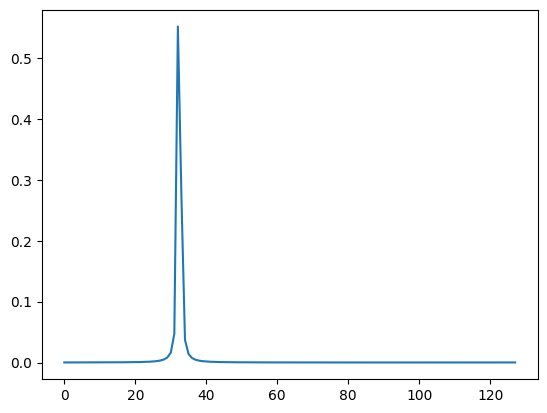

In [200]:
n = 7
k = np.random.choice(7)
theta = 2**(n - k - 1) + np.random.random()
# n, 2**n, theta 
print(f'theta is {theta}')

fejer_distribution = Statevector(fejer_circuit).probabilities()

fejer_circuit = fejer_prep(theta,n)
fejer_distribution = Statevector(fejer_circuit).probabilities()
plt.plot(np.arange(2**n), fejer_distribution)


theta_low = int(np.floor(theta))
theta_high = int(np.ceil(theta))

print(f'the probability of measuring the floor of theta is {fejer_distribution[theta_low]}')
print(f'the probability of measuring the ceiling of theta is {fejer_distribution[theta_high]}')

print(f'the probability of measuring either floor or ceiling is {fejer_distribution[theta_low] + fejer_distribution[theta_high]}')
print(f'compared to 8 / pi^2 , which is around {8 / np.pi**2}')

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

---------------------------------
## Quantum Phase Estimation


Suppose that we have 

1. A unitary transformation $U \in \mathcal{U}(\mathcal{H})$

2. An eigenstate $\ket{\psi} \in \mathcal{H}$, so that for some $0 \leq \theta < 1$,

$$
U \ket{\psi}  = e^{2 \pi \theta i } \ket{\psi} 
$$

The aim of the QPE algorithm is to try to extract the value of $\theta$, or at least extract a sufficiently good approximation of $\theta$. 

If we grant the following assumptions, we show that we can design a quantum circuit that does exactly this. 

<u> Assumptions: </u> 

1. We can implement $U$ as a gate, as well as controlled versions of any power $U^{l}$ of $U$. That is, for any $l$, we assume that we have a way to implement the gate
$C(U^{l})( \ket{x} \otimes \ket{ \phi } ) = \ket{ x }  \otimes  U^{l}  \ket{\phi} $ 

2. We have a way to prepare the eigenstate $\ket{\psi}$


We present a schematic of the QPE circuit below. 


<img src="qpecircuit.jpg" style="display: block; margin: auto; width: 75%">



$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$

We split the register into two parts: one $n$-qubit register $\ket{x_{1}, \cdots, x_{n}}$ that will encode an approximation of $\theta$, and another register prepared in the eigenstate $\ket{\psi}$. The eigenstate $\ket{\psi}$ is passed through gates $U^{2^{l}}$ controlled on the corresponding qubit $\ket{x_{l}}$ in the first register. 

Let's trace out the effect of this circuit. We begin with the state $\ket{0}_{n} \ket{\psi}$. Then, we compose the actions and obtain

$$
\begin{align*}
& \ket{0}_{n} \ket{\psi} \xrightarrow{H^{\otimes n} \otimes I} \frac{1}{2^{n/2}} \sum\limits_{x} \ket{x} \ket{\psi} \xrightarrow{CU} \frac{1}{2^{n/2}} U^{x_{0}} \ket{\psi} =  \frac{1}{2^{n/2}} \sum\limits_{x} e^{2 \pi i \theta x_{0} } \ket{x} \ket{\psi}    \\
& \xrightarrow{CU^{2}} \frac{1}{2^{n/2}} \sum\limits_{x} e^{2 \pi i \theta x_{0} } \ket{x} U^{2x_{1}} \ket{\psi}  = \frac{1}{2^{n/2}} \sum\limits_{x} e^{2 \pi i \theta (x_{0}  + 2 x_{1}) } \ket{x} \ket{\psi} \\ 
& \xrightarrow{CU^{3}} \cdots \\
& \cdots\\
& \xrightarrow{CU^{2^{n-1}}}   \frac{1}{2^{n/2}} \sum\limits_{x} e^{2 \pi i \theta (x_{0}  + 2 x_{1}  + 2^{2} x_{2} + \cdots 2^{n-1} x_{n-1} ) } \ket{x} \ket{\psi} \\
& = \frac{1}{2^{n/2}} \sum\limits_{x} e^{2 \pi i \theta x } \ket{x} \ket{\psi} = \frac{1}{2^{n/2}} \big(A^{QFT}( 2^{n} \theta )  \ket{x} \big)  \ket{\psi}\\
& \xrightarrow{ \text{QFT}^{\dagger} \otimes \mathbb{I} }  \text{QFT}^{\dagger} \Big(  A^{QFT}( 2^{n} \theta )  \ket{x}     \Big) \ket{\psi} \\
& = \ket{ 2^{n} \theta }_{F} \ket{\psi}
\end{align*}
$$

In other words, the QPE circuit acts on the initial state $\ket{0}_{n} \ket{\psi}$ as

$$
\text{QPE}_{U} \Big( \ket{0}_{n} \ket{\psi} \Big) = \ket{ 2^{n} \theta }_{F} \ket{\psi}
$$

This means that if we measure the first $n$ qubits, we will measure an integer $x$ with probability 

$$
\mathbb{P} \Big(  x \mid  \ket{ 2^{n} \theta }_{F} \Big) = \frac{ \sin^{2} ( \pi( x - 2^{n} \theta ) ) }{ 4^{n} \sin^{2} (  \frac{\pi}{2^{n} } ( x - 2^{n} \theta )  )}
$$

in turn, this means that with probability $\geq 0.81$ we will measure either $\lfloor 2^{n} \theta \rfloor$ or $\lceil 2^{n} \theta \rceil$. Let us denote the more likely one as $x_{0}$.  Then, we will have an approximation:

$$
\theta \approx \frac{x_{0}}{2^{n}}
$$

This is an approximation of $\theta$ as a dyadic rational number. The role of $n$ here is the precision of the approximation. If $\theta$ itself is an $n$-bit dyadic rational, then $2^{n} \theta$ will be an integer, and the Fejér state $\ket{ 2^{n} \theta}_{F}$ will measure $2^{n} \theta$ with certainty. Otherwise, what we have here is a probabilistic algorithm (with a fairly high success rate, with a lower bound of around 81% that does not depend on $n$!) that produces upon measurement, the closest dyadic rational number $\frac{x_{0}}{2^{n}}$ to $\theta$. 

------------

The Jupyter notebook for Part III can be found [here](https://github.com/elhyc/qcfieldscourse/blob/main/qc3.ipynb)